In [47]:
%load_ext autoreload
%autoreload 2
import sys

ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [2]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)  # Only if you're adding a new font file
fm._load_fontmanager(try_read_cache=False)

# HumanCT IQ Phenotype


In [3]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

In [4]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
Mut_n_IQ.columns.values

array(['IID', 'Sex', 'Pheno', 'VarID', 'GeneID', 'HGNC', 'GeneEff',
       'REVEL', 'ExACpLI', 'Entrez', 'IQ'], dtype=object)

In [5]:
Spark_Denovo = pd.read_excel("../dat/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo_ExomeWide = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]<=1.3e-6]
Spark_Denovo_ExomeWide.shape

(61, 56)

In [6]:
top_Genes = Spark_Denovo.head(61)["HGNC"].values
Mut_n_IQ_conf = Mut_n_IQ[Mut_n_IQ["HGNC"].isin(top_Genes)]
Mut_n_IQ_conf.shape

(221, 11)

In [7]:
#### Gene Level
Genes = list(set(Mut_n_IQ_conf["Entrez"].values))
data = []
for g in Genes:
    tmp_df = Mut_n_IQ_conf[Mut_n_IQ_conf["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF = pd.DataFrame(data=data, columns=columns)

In [9]:
HumanCT_res_df_MutL = Make_HumanCT_DF(Mut_n_IQ_conf, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.spec.MutL.csv")
HumanCT_res_df_GeneL = Make_HumanCT_DF(Avg_Gene_IQ_DF, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.spec.GeneL.csv")

In [10]:
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="LAMP5-LHX6 and Chandelier"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="MGE interneuron"]["beta"]))

-15.419037348555849
-15.374304370403467
-15.4281167460514


In [11]:
HumanCT_res_df_GeneL.head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330
266,266,LAMP5-LHX6 and Chandelier,-0.470757,0.000251,-0.353220,0.007578,-14.405018,-24.814352,-3.995684,64.630648,0.124764,0.007578,5.192000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708
265,265,LAMP5-LHX6 and Chandelier,-0.404936,0.001964,-0.346602,0.008873,-14.334666,-24.918809,-3.750523,64.130645,0.120133,0.008873,5.279192
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977
269,269,LAMP5-LHX6 and Chandelier,-0.389574,0.003000,-0.381814,0.003688,-16.304049,-27.071661,-5.536437,65.611086,0.145782,0.003688,5.370704


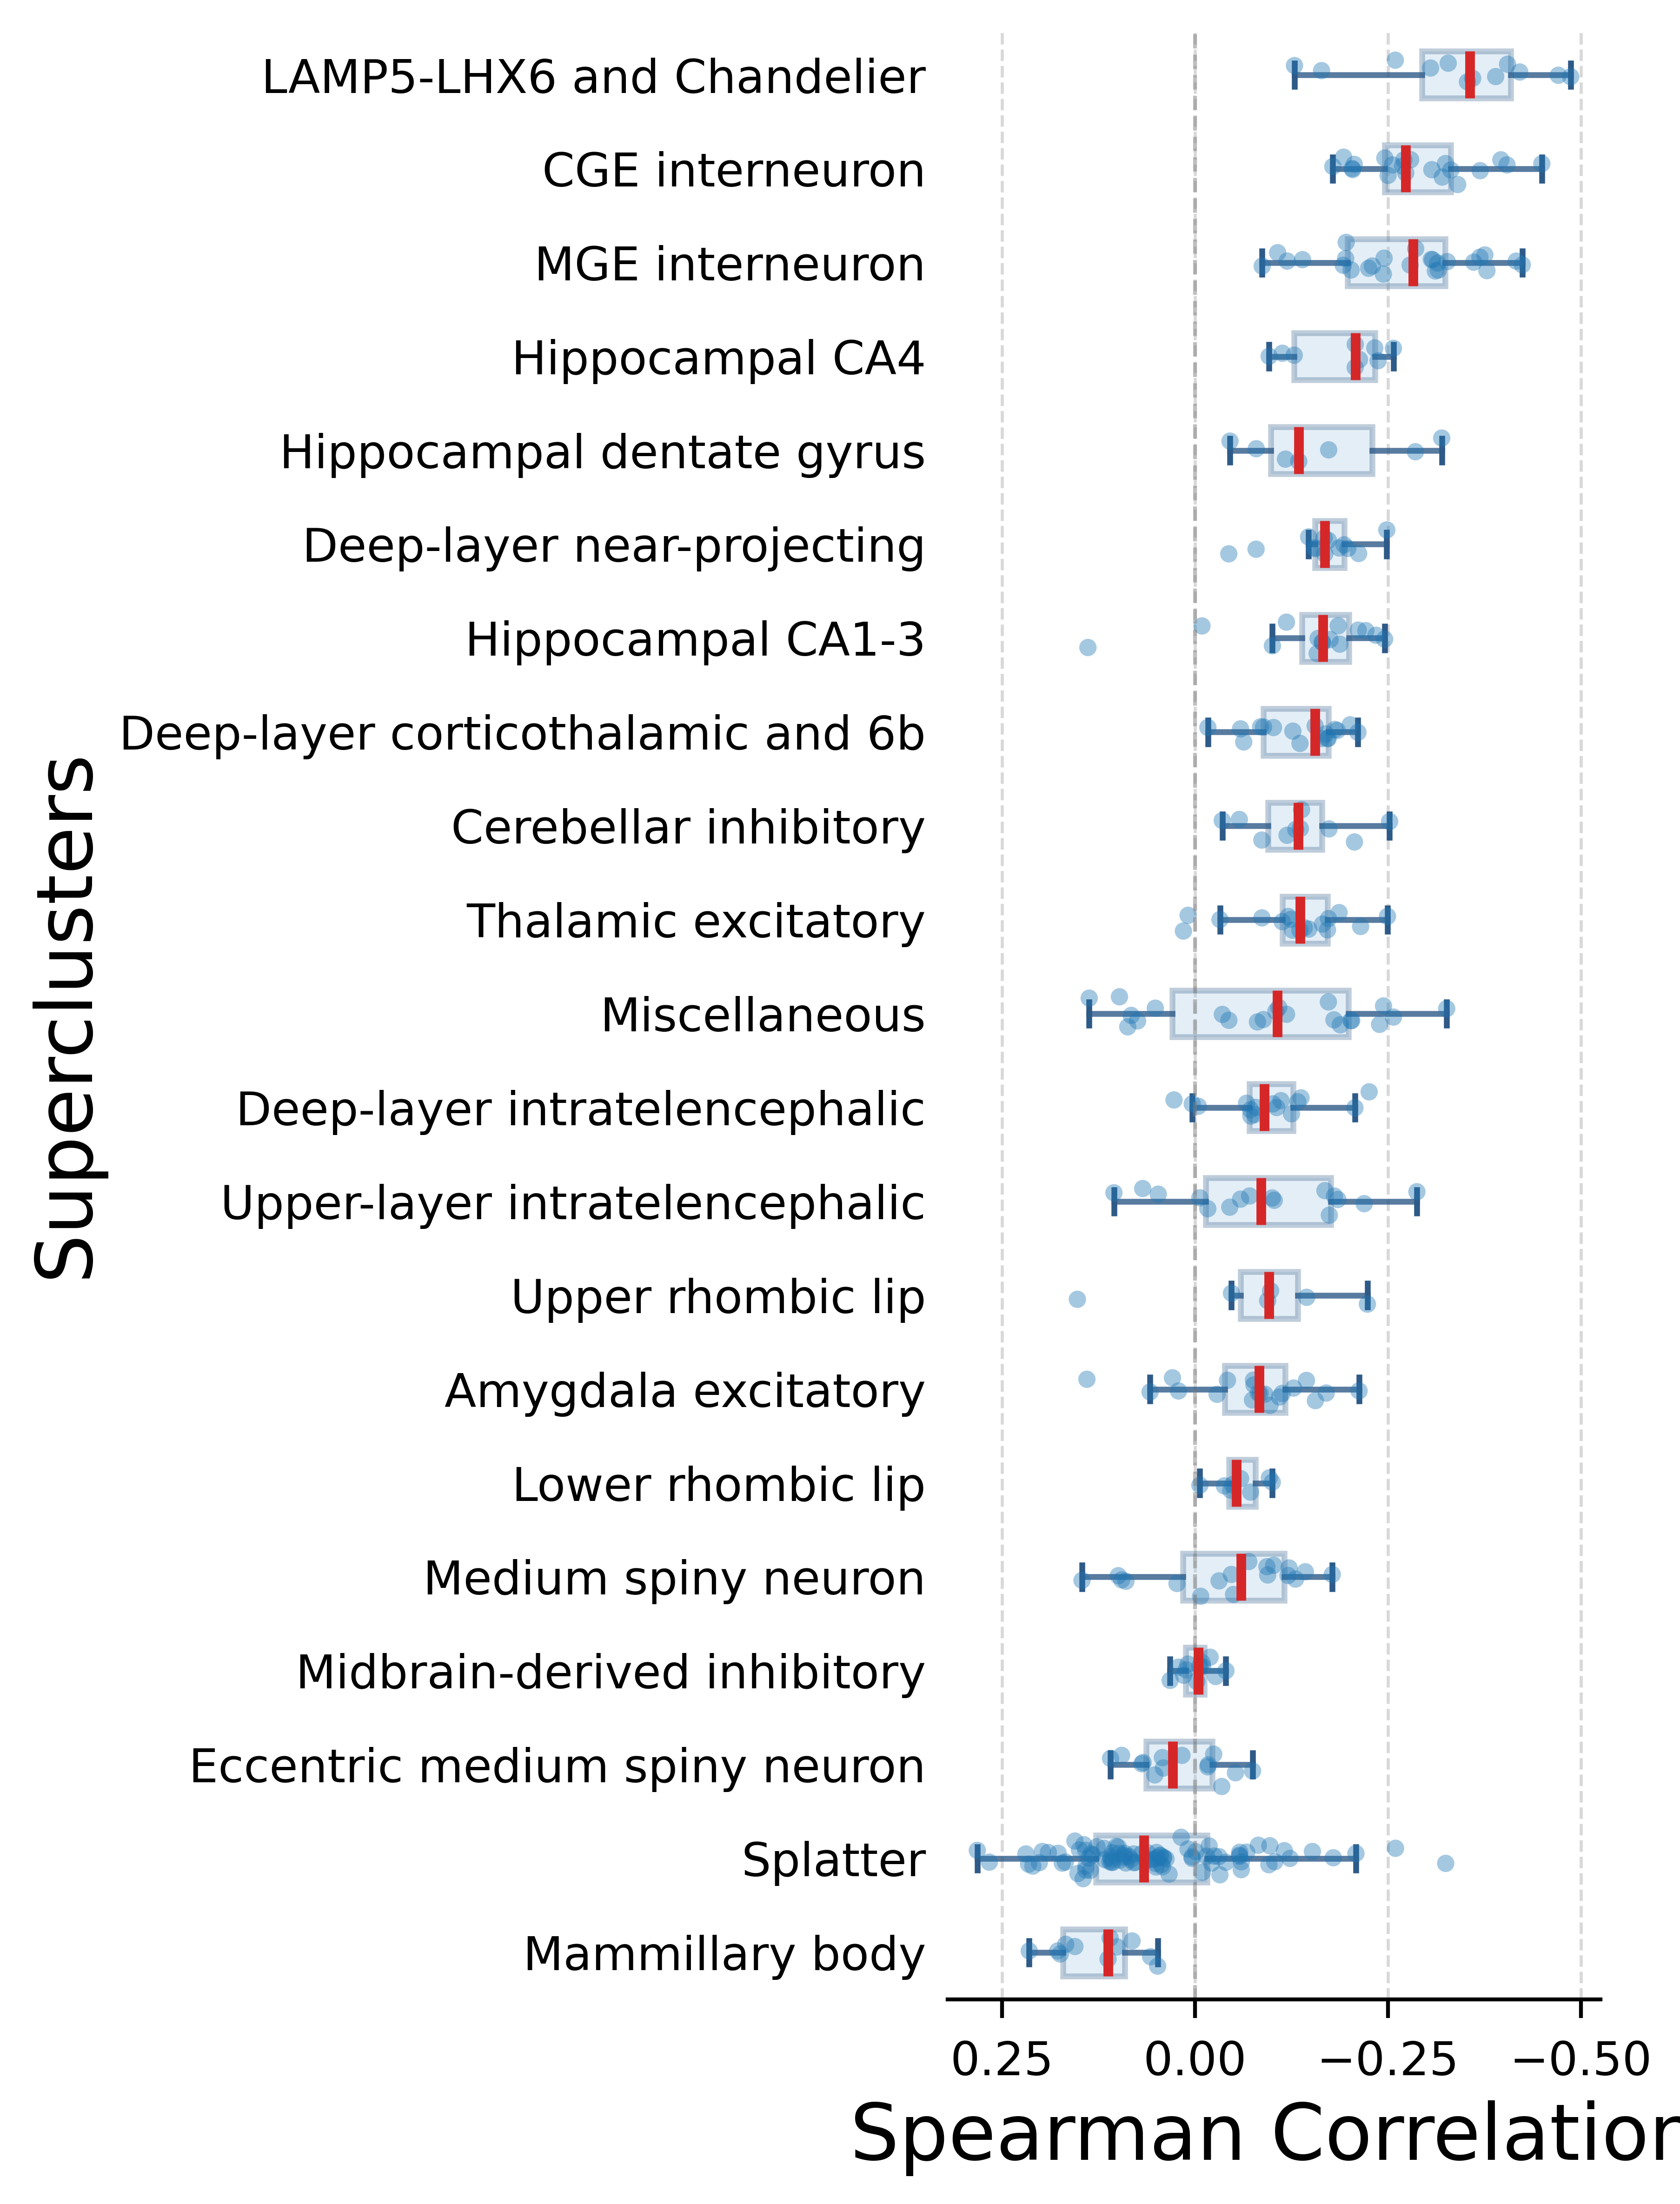

In [12]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="SpearmanR")

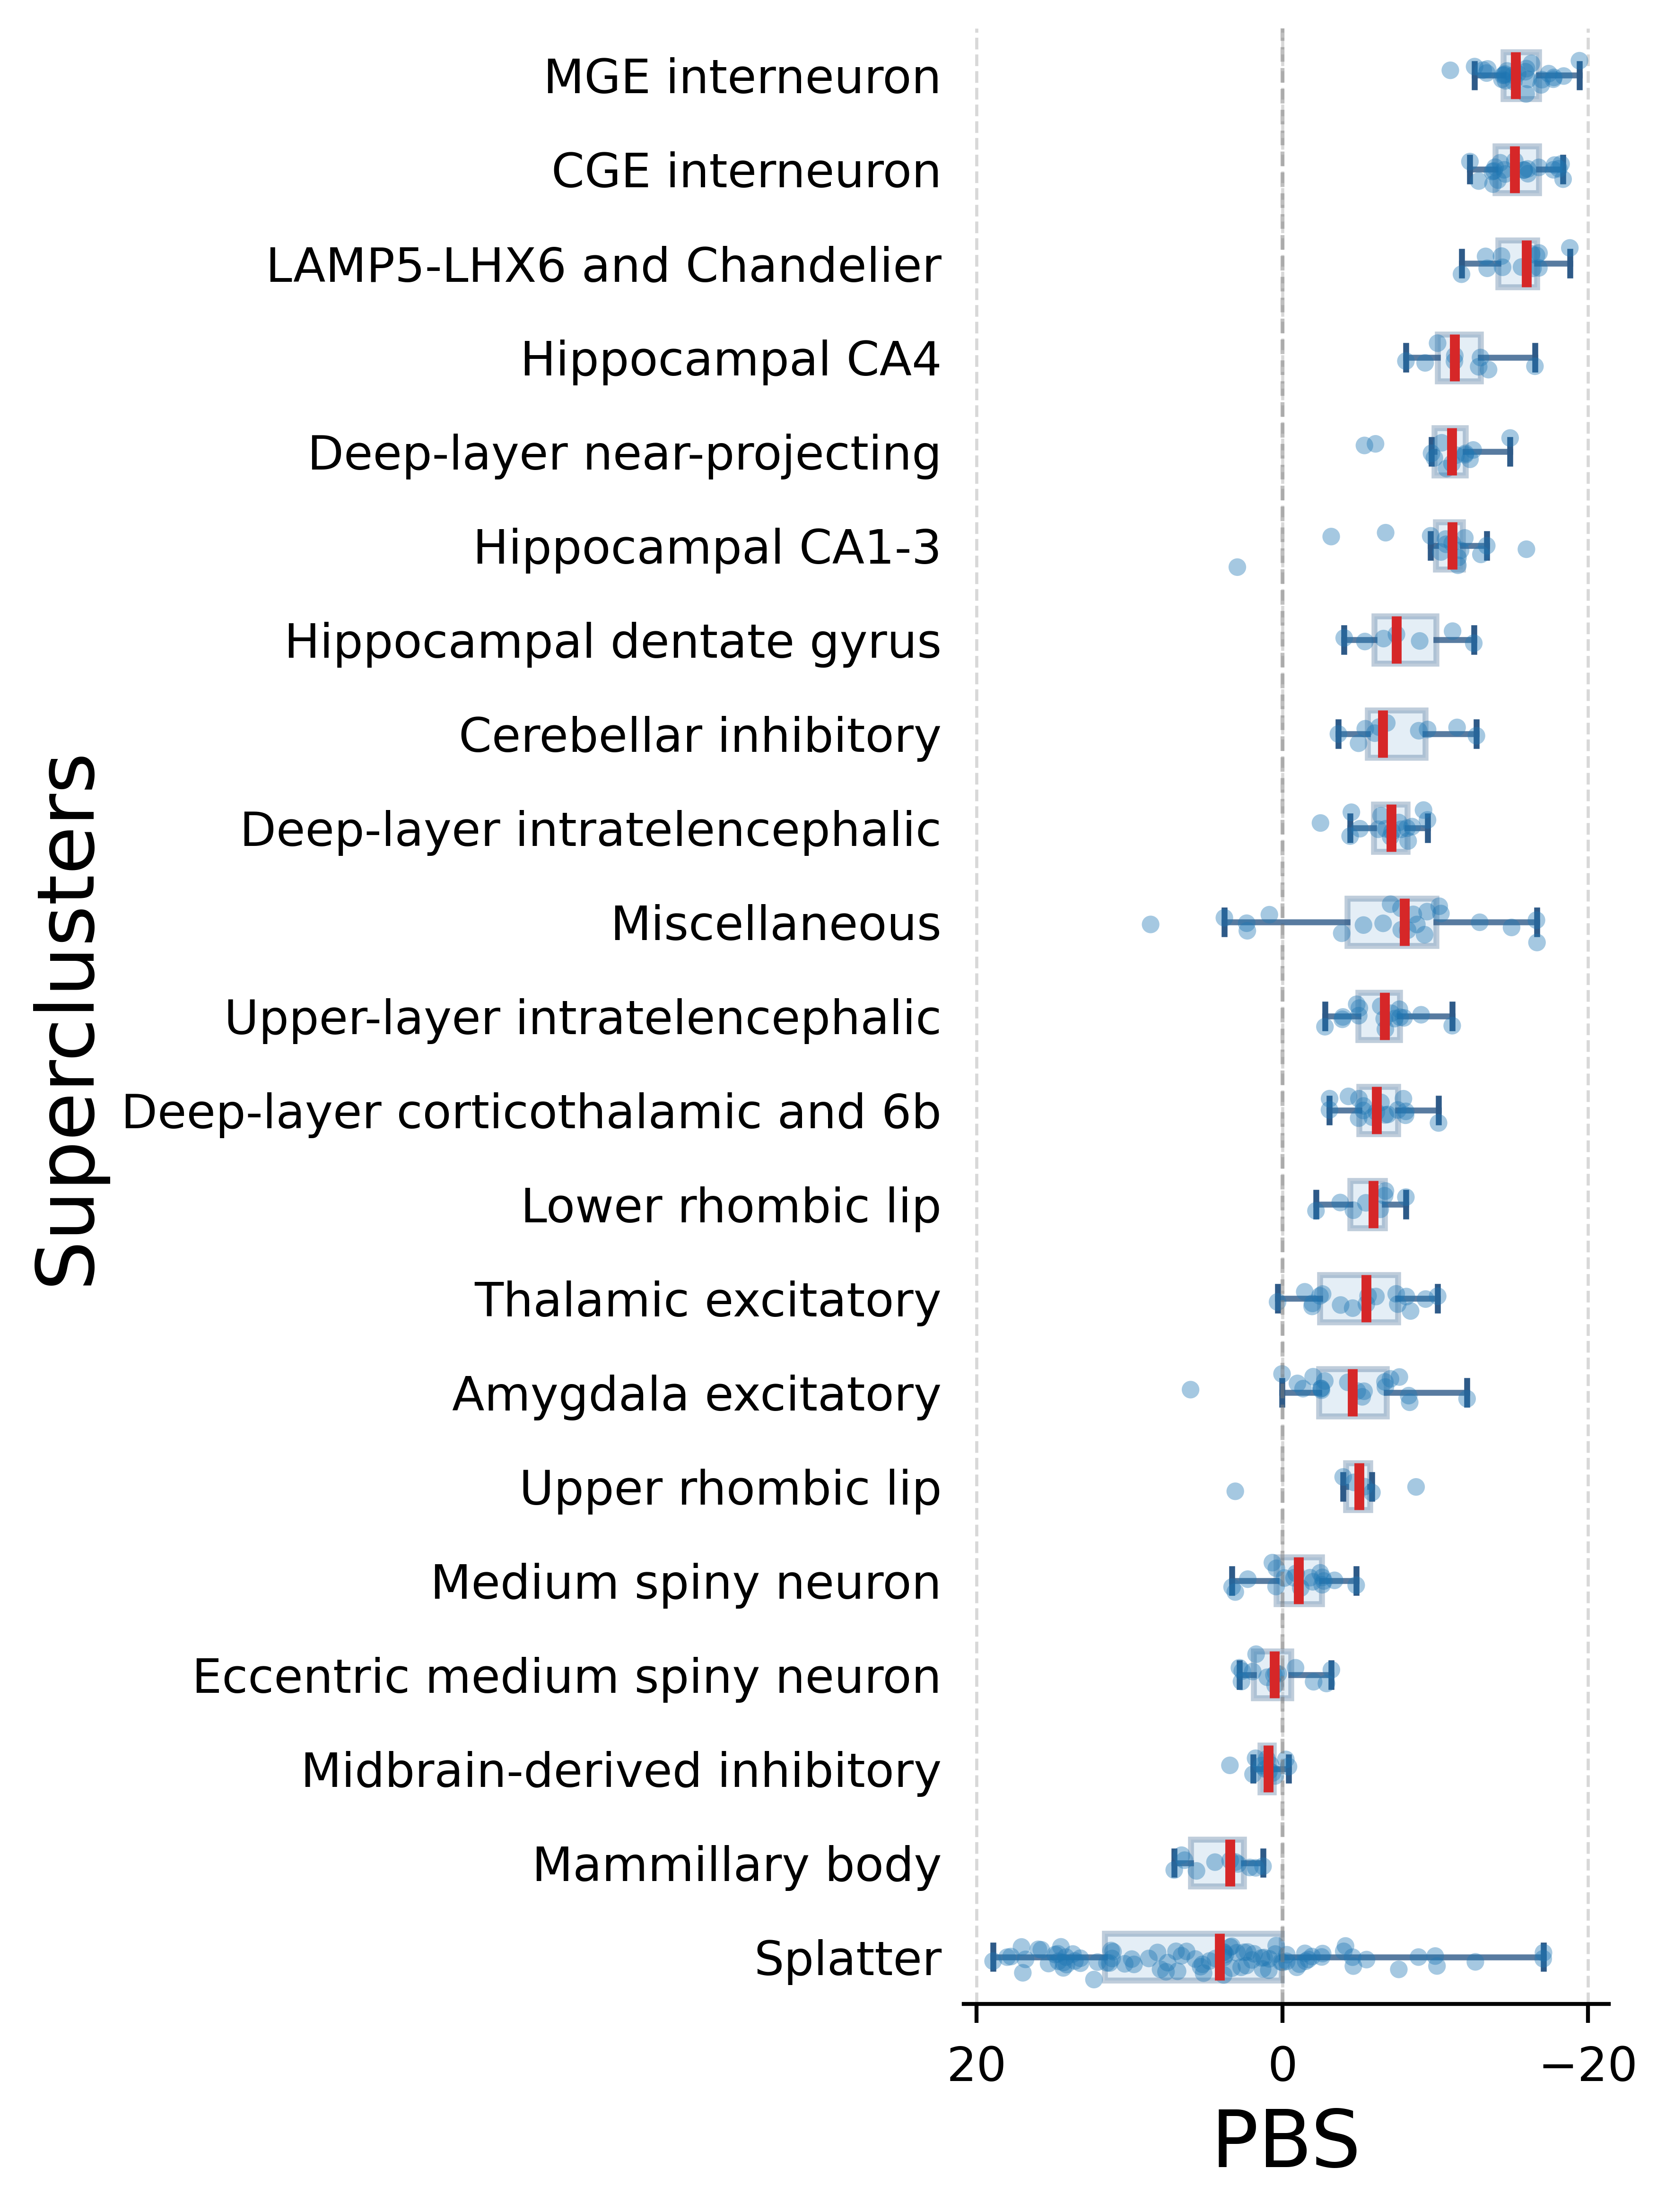

In [13]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="beta")

In [14]:
VIP_Anno = pd.read_csv("VIP_Anno.csv", index_col=0)

In [15]:
# Get subset of rows from VIP_Anno that exist in X22q_Z2_Bias_PT
common_indices = HumanCT_res_df_GeneL.index.intersection(VIP_Anno.index)
HumanCT_res_df_GeneL_sub = HumanCT_res_df_GeneL.loc[common_indices].copy()
HumanCT_res_df_GeneL_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

/tmp/ipykernel_249261/2630822850.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


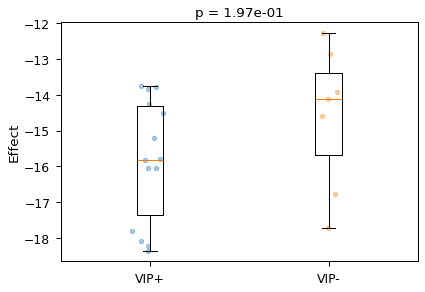

In [16]:
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
data = [HumanCT_res_df_GeneL_sub_VIP_pos["beta"], HumanCT_res_df_GeneL_sub_VIP_neg["beta"]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos["beta"], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg["beta"])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos["beta"], HumanCT_res_df_GeneL_sub_VIP_neg["beta"]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()


/tmp/ipykernel_249261/3396741605.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


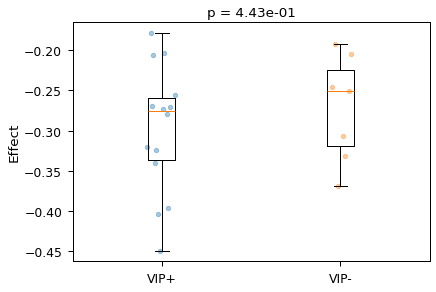

In [17]:
Effect = "SpearmanR"
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
data = [HumanCT_res_df_GeneL_sub_VIP_pos[Effect], HumanCT_res_df_GeneL_sub_VIP_neg[Effect]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos[Effect], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg[Effect])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos[Effect], HumanCT_res_df_GeneL_sub_VIP_neg[Effect]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()

### Mut IQ permutation

In [18]:
Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_June13/ALL/"
Perm_DFs = []
for df in os.listdir(Perm_DIR):
    df = pd.read_csv(f"{Perm_DIR}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs.append(df)
print(len(Perm_DFs))

10000


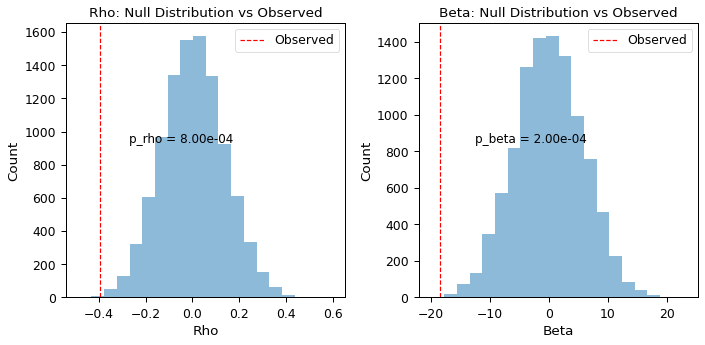

(0.0008, 0.0002)

In [20]:
plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=295, plot=True)

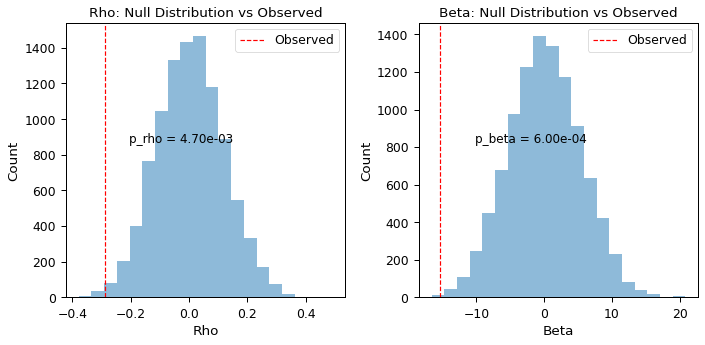

In [21]:
Supercluster = "CGE interneuron"
ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values

p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=True)

In [22]:
#Supercluster = "CGE interneuron"
# Create DataFrame to store results
results_df = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=False)
    
    # Add results to DataFrame
    results_df = results_df.append({
        'Supercluster': Supercluster,
        "mean_PBS": HumanCT_res_df_GeneL.loc[ClusterIdx, "beta"].mean(),
        'p_rho': p_rho,
        'p_beta': p_beta
    }, ignore_index=True)

/tmp/ipykernel_249261/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_249261/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_249261/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_249261/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_249261/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


In [23]:
# Add FDR corrected p-values
results_df['p_rho_FDR'] = multipletests(results_df['p_rho'], method='fdr_bh')[1]
results_df['p_beta_FDR'] = multipletests(results_df['p_beta'], method='fdr_bh')[1]

results_df.sort_values("p_beta")

,Supercluster,p_rho,p_beta,mean_PBS,p_rho_FDR,p_beta_FDR
1,CGE interneuron,0.0047,0.0006,-15.419037,0.049350,0.012600
10,LAMP5-LHX6 and Chandelier,0.0019,0.0015,-15.374304,0.039900,0.015750
12,MGE interneuron,0.0090,0.0024,-15.428117,0.063000,0.016800
8,Hippocampal CA4,0.0715,0.0116,-11.769164,0.250950,0.060900
7,Hippocampal CA1-3,0.0945,0.0164,-9.898502,0.250950,0.068880
16,Miscellaneous,0.0728,0.0203,-6.665898,0.250950,0.071050
5,Deep-layer near-projecting,0.0956,0.0295,-10.643747,0.250950,0.086362
9,Hippocampal dentate gyrus,0.0932,0.0329,-8.023036,0.250950,0.086362
2,Cerebellar inhibitory,0.1210,0.0383,-7.582115,0.257670,0.089367
20,Upper-layer intratelencephalic,0.1958,0.0851,-6.460426,0.316292,0.169336


In [24]:
for i, row in HumanCT_res_df_GeneL.iterrows():
    ct = int(row["CT"])
    p_rho, p_beta = plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=ct, plot=False)
    HumanCT_res_df_GeneL.loc[i, "p_rho_perm"] = p_rho
    HumanCT_res_df_GeneL.loc[i, "p_beta_perm"] = p_beta
#HumanCT_res_df_GeneL.sort_values("p_beta_FDR")

In [25]:
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"].isin(Neurons)]

In [26]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("p_beta_perm")
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL_neuron.sort_values("p_beta_perm")
print(HumanCT_res_df_GeneL.shape, HumanCT_res_df_GeneL_neuron.shape)


(461, 15) (382, 15)


In [42]:
def safe_neglog10(x):
    val = -np.log10(x)
    if np.isinf(val):
        return 4.0 # 4.0 is the max value for p-values, change according to number of permutations (10,000)
    return val

HumanCT_res_df_GeneL["p_beta_perm_Log"] = HumanCT_res_df_GeneL["p_beta_perm"].apply(safe_neglog10)

In [40]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("p_beta_perm")
HumanCT_res_df_GeneL.head(5)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_beta_perm_Log,p_rho_perm_FDR,p_beta_perm_FDR
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,4.00000,0.015367,0.000000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,4.00000,0.015367,0.015367
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,3.69897,0.046100,0.015367
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,3.69897,0.046100,0.015367
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,3.69897,0.046100,0.015367


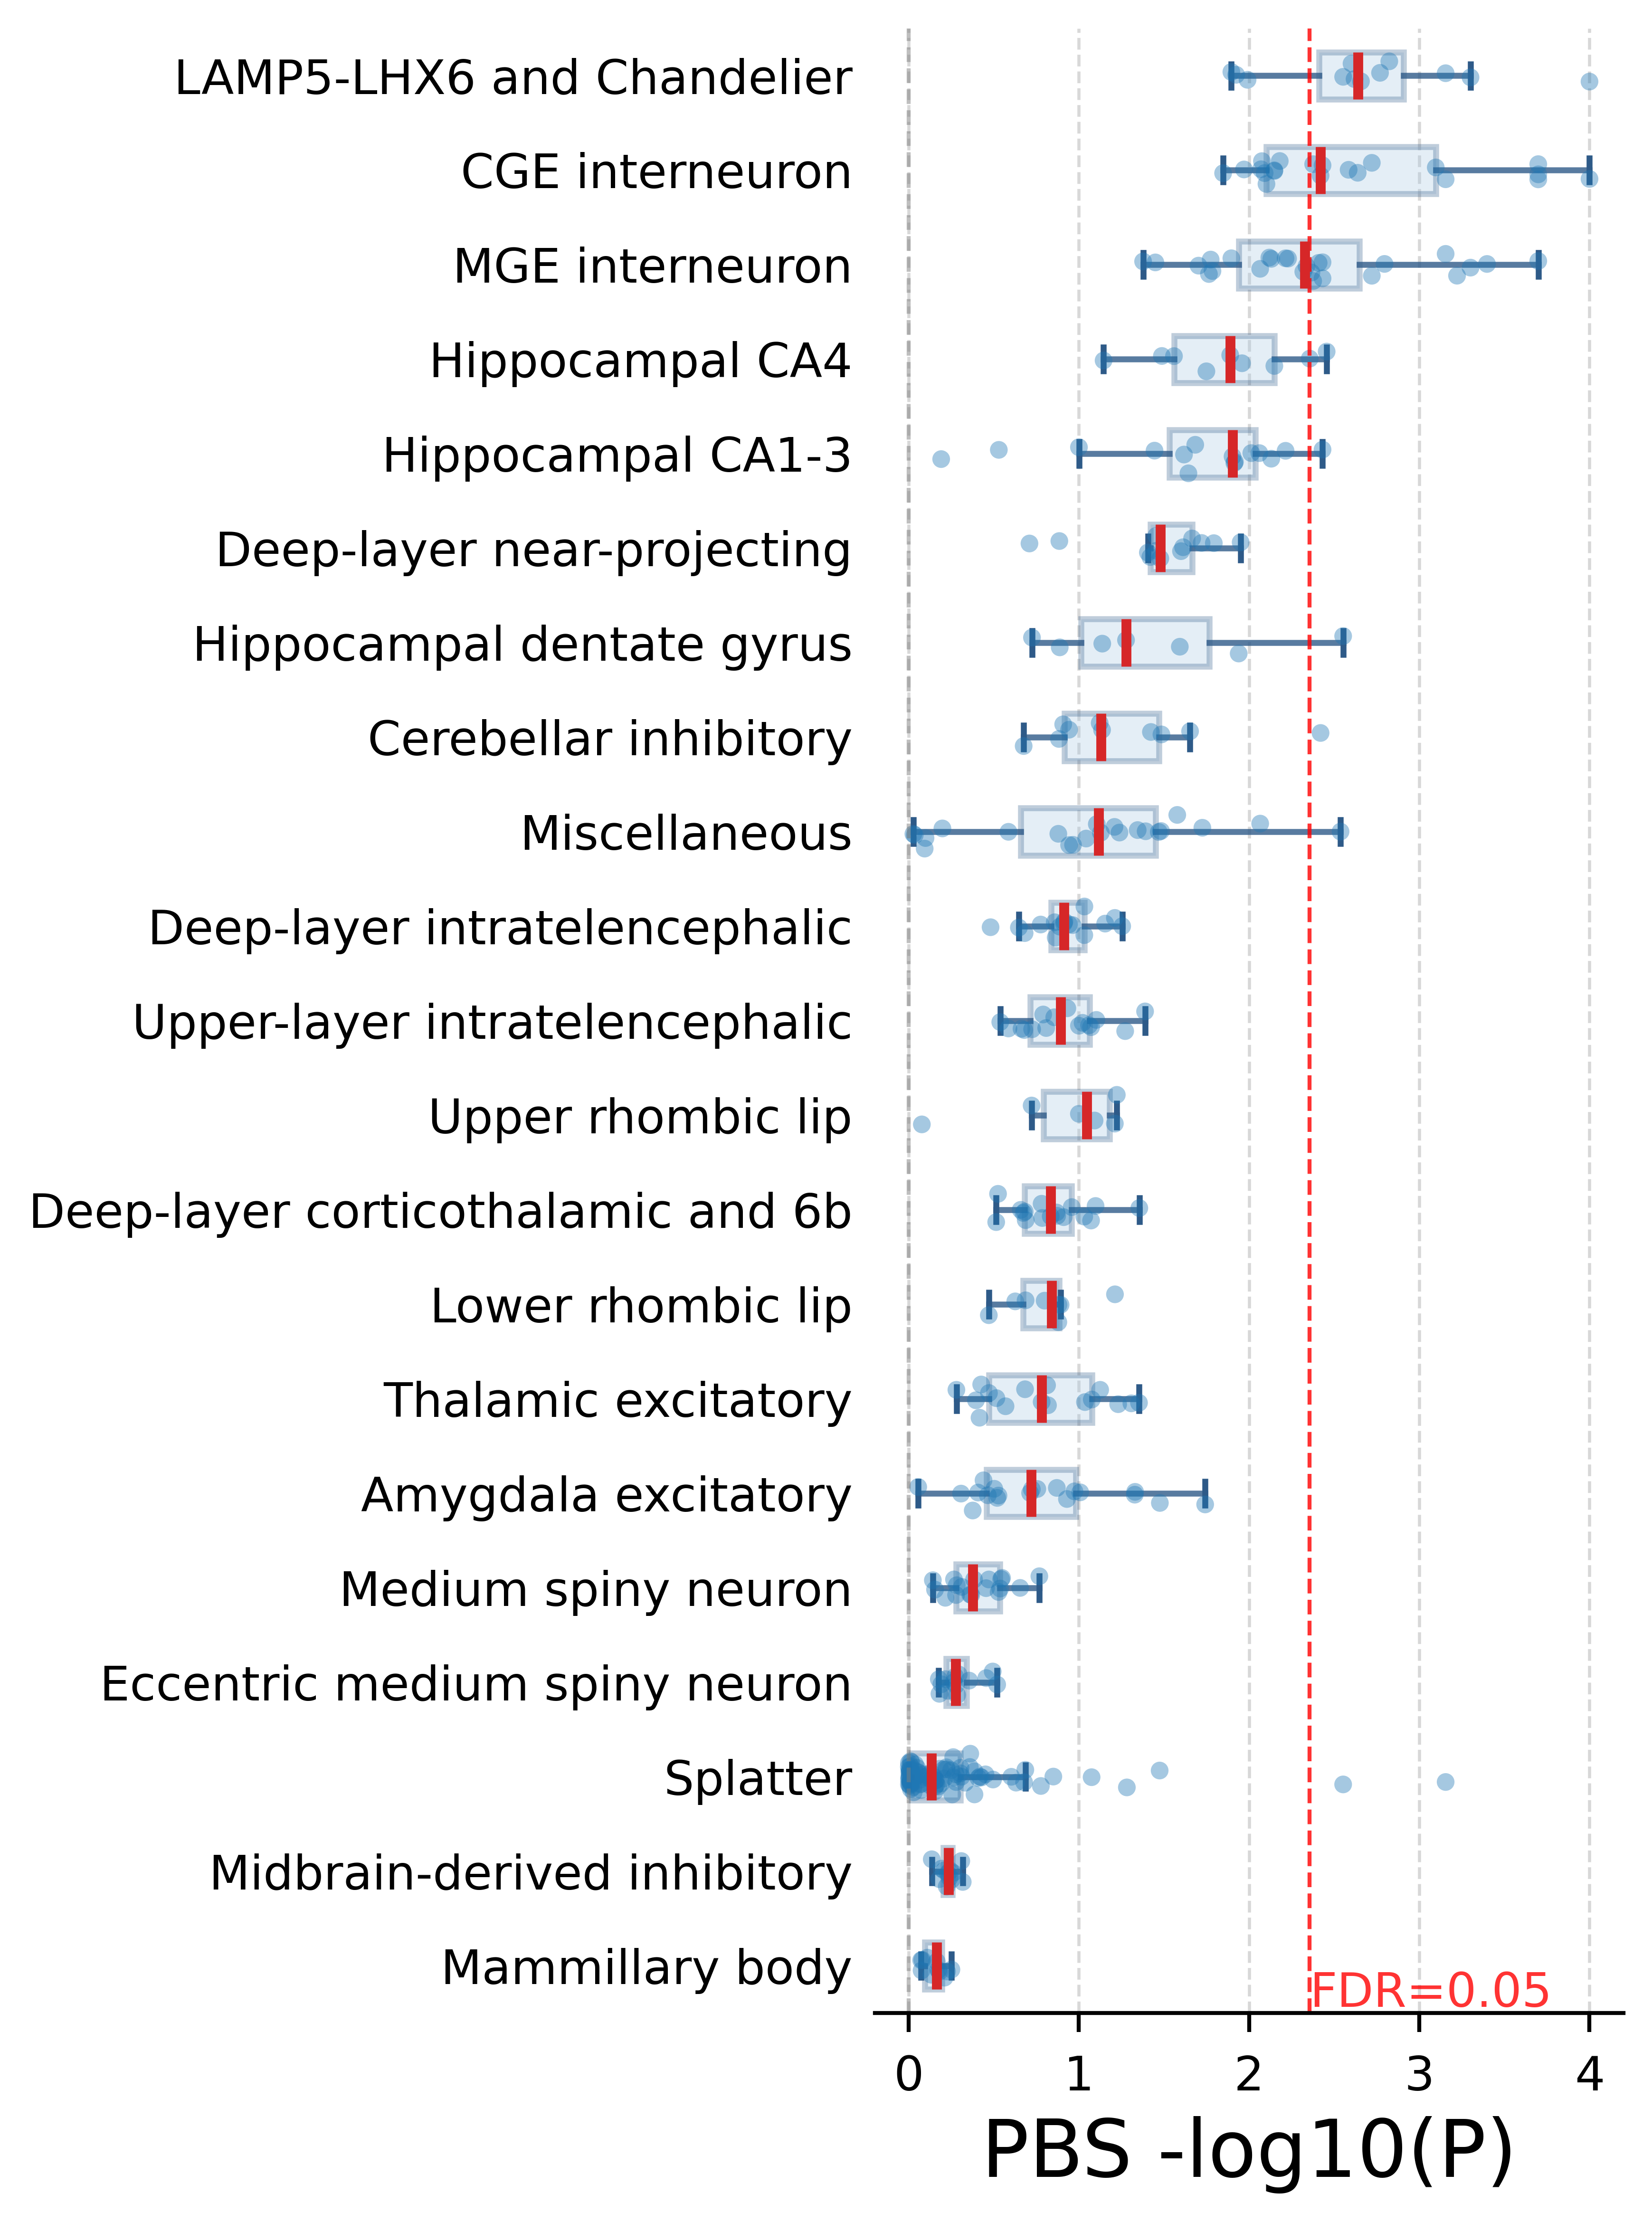

In [55]:
#umanCT_res_df_GeneL
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=False, figsize=(6, 8), plot_metric="p_beta_perm_Log", xlabel="PBS -log10(P)")

In [59]:
common_indices = HumanCT_res_df_GeneL.index.intersection(VIP_Anno.index)
HumanCT_res_df_GeneL_sub = HumanCT_res_df_GeneL.loc[common_indices].copy()
HumanCT_res_df_GeneL_sub["VIP"] = VIP_Anno.loc[common_indices, "VIP"]

/tmp/ipykernel_249261/1336434826.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


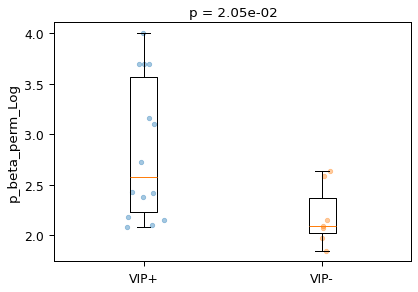

In [62]:
HumanCT_res_df_GeneL_sub_VIP_pos = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] >= 1]
HumanCT_res_df_GeneL_sub_VIP_neg = HumanCT_res_df_GeneL_sub[HumanCT_res_df_GeneL_sub["VIP"] < 1]
# plot effect of VIP+ vs VIP-
#EFFECT = "beta"
EFFECT = "p_beta_perm_Log"
data = [HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], 
                                    HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT])
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([HumanCT_res_df_GeneL_sub_VIP_pos[EFFECT], HumanCT_res_df_GeneL_sub_VIP_neg[EFFECT]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel(EFFECT)
plt.title(f"p = {pval:.2e}")
plt.show()


In [30]:
HumanCT_res_df_GeneL['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_beta_perm'], method='fdr_bh')[1]

HumanCT_res_df_GeneL_neuron['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL_neuron['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_beta_perm'], method='fdr_bh')[1]

In [31]:
HumanCT_res_df_GeneL_neuron.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,0.012733,0.000000
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,0.012733,0.012733
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,0.118238,0.012733
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,0.038200,0.012733
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,0.038200,0.012733
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,0.038200,0.012733
239,239,MGE interneuron,-0.424077,0.001125,-0.405046,0.001957,-16.983547,-27.442845,-6.524249,65.529179,0.164062,0.001957,5.216921,0.0008,0.0004,0.038200,0.019100
268,268,LAMP5-LHX6 and Chandelier,-0.420761,0.001242,-0.387999,0.003129,-16.778903,-27.653043,-5.904763,65.083869,0.150543,0.003129,5.423838,0.0004,0.0005,0.038200,0.019100
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822,0.0021,0.0005,0.068760,0.019100
260,260,MGE interneuron,-0.369149,0.005114,-0.371696,0.004793,-16.926226,-28.460170,-5.392282,64.769167,0.138158,0.004793,5.752937,0.0027,0.0006,0.068760,0.019100


In [32]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("beta")

In [33]:
HumanCT_res_df_GeneL.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_beta_perm_Log,p_rho_perm_FDR,p_beta_perm_FDR
236,236,MGE interneuron,-0.375602,0.004336,-0.391401,0.002855,-19.434111,-31.900093,-6.968130,64.516750,0.153194,0.002855,6.217822,0.0021,0.0005,3.301030,0.082980,0.023050
267,267,LAMP5-LHX6 and Chandelier,-0.486729,0.000143,-0.420311,0.001259,-18.804361,-29.879975,-7.728747,65.070604,0.176662,0.001259,5.524330,0.0001,0.0000,inf,0.015367,0.000000
259,259,MGE interneuron,-0.416215,0.001420,-0.404499,0.001988,-18.401806,-29.752848,-7.050764,64.891071,0.163620,0.001988,5.661708,0.0005,0.0002,3.698970,0.046100,0.015367
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,0.170924,0.001540,5.503977,0.0008,0.0002,3.698970,0.046100,0.015367
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,0.177156,0.001237,5.347181,0.0006,0.0002,3.698970,0.046100,0.015367
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,0.181508,0.001061,5.225758,0.0001,0.0001,4.000000,0.015367,0.015367
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,0.164945,0.001898,5.452727,0.0064,0.0002,3.698970,0.142690,0.015367
240,240,MGE interneuron,-0.378241,0.004050,-0.383223,0.003554,-17.758245,-29.435741,-6.080749,65.525407,0.146860,0.003554,5.824538,0.0026,0.0007,3.154902,0.082980,0.023050
286,286,CGE interneuron,-0.306867,0.021426,-0.360944,0.006277,-17.734122,-30.235279,-5.232965,65.051352,0.130281,0.006277,6.235366,0.0125,0.0023,2.638272,0.174621,0.046100
257,257,MGE interneuron,-0.225006,0.095461,-0.332159,0.012383,-17.722334,-31.452641,-3.992027,63.751094,0.110330,0.012383,6.848446,0.0465,0.0059,2.229148,0.351418,0.061133


In [66]:
HumanCT_res_df_GeneL.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.June10.csv")
results_df = results_df.sort_values("p_beta")
results_df.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Supercluster.June10.csv")

In [67]:
results_df

,Supercluster,p_rho,p_beta,mean_PBS,p_rho_FDR,p_beta_FDR
1,CGE interneuron,0.0047,0.0006,-15.419037,0.049350,0.012600
10,LAMP5-LHX6 and Chandelier,0.0019,0.0015,-15.374304,0.039900,0.015750
12,MGE interneuron,0.0090,0.0024,-15.428117,0.063000,0.016800
8,Hippocampal CA4,0.0715,0.0116,-11.769164,0.250950,0.060900
7,Hippocampal CA1-3,0.0945,0.0164,-9.898502,0.250950,0.068880
16,Miscellaneous,0.0728,0.0203,-6.665898,0.250950,0.071050
5,Deep-layer near-projecting,0.0956,0.0295,-10.643747,0.250950,0.086362
9,Hippocampal dentate gyrus,0.0932,0.0329,-8.023036,0.250950,0.086362
2,Cerebellar inhibitory,0.1210,0.0383,-7.582115,0.257670,0.089367
20,Upper-layer intratelencephalic,0.1958,0.0851,-6.460426,0.316292,0.169336


#### Test VIP+ and VIP-

In [68]:
CGE_VIP_Pos_list = np.loadtxt("../dat/Other/CGE_VIP_Pos.txt", dtype=int)
CGE_VIP_Neg_list = np.loadtxt("../dat/Other/CGE_VIP_Neg.txt", dtype=int)

In [69]:
VIP_pos_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
VIP_neg_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
DIFF_obs = VIP_pos_meanPBS - VIP_neg_meanPBS
print(VIP_pos_meanPBS, VIP_neg_meanPBS, VIP_pos_meanPBS - VIP_neg_meanPBS)

-15.82619395310754 -14.604724139452458 -1.221469813655082


In [70]:
null_diffs = []
for i in range(10000):
    tmpDF = Perm_DFs[i]
    tmp_VIP_pos_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
    tmp_VIP_neg_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
    null_diffs.append(tmp_VIP_pos_meanPBS - tmp_VIP_neg_meanPBS)
null_diffs = np.array(null_diffs)

Observed difference: -1.221
P-value: 2.834e-01


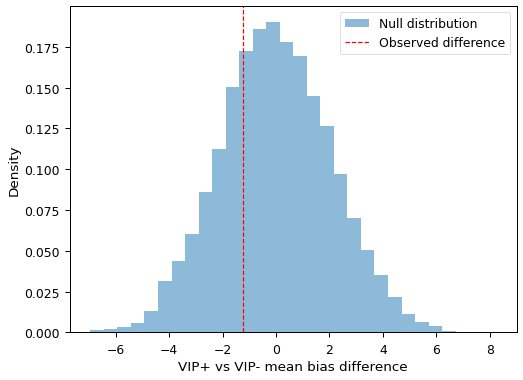

In [71]:
# Plot observed difference vs null distribution
plt.figure(figsize=(8,6))
plt.hist(null_diffs, bins=30, density=True, alpha=0.5, label='Null distribution')
plt.axvline(DIFF_obs, color='red', linestyle='dashed', label='Observed difference')
plt.xlabel('VIP+ vs VIP- mean bias difference')
plt.ylabel('Density')
plt.legend()

#compute 1-sided p-value
pval = np.mean(null_diffs <= DIFF_obs)
print(f"Observed difference: {DIFF_obs:.3f}")
print(f"P-value: {pval:.3e}")

### LGD vs Dmis

In [72]:
Mut_n_IQ_conf_LGD = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]!="missense"]
Mut_n_IQ_conf_Dmis = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]=="missense"]
print(Mut_n_IQ_conf.shape, Mut_n_IQ_conf_LGD.shape, Mut_n_IQ_conf_Dmis.shape)

(221, 11) (149, 11) (72, 11)


In [73]:
# Calculate gene level for Mut_n_IQ_conf
Genes_LGD = list(set(Mut_n_IQ_conf_LGD["Entrez"].values))
data_LGD = []
for g in Genes_LGD:
    tmp_df = Mut_n_IQ_conf_LGD[Mut_n_IQ_conf_LGD["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_LGD.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF_LGD = pd.DataFrame(data=data_LGD, columns=columns)

# Calculate gene level for Mut_n_IQ_Dmis
Genes_Dmis = list(set(Mut_n_IQ_conf_Dmis["Entrez"].values))
data_Dmis = []
for g in Genes_Dmis:
    tmp_df = Mut_n_IQ_conf_Dmis[Mut_n_IQ_conf_Dmis["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_Dmis.append(row)
Avg_Gene_IQ_DF_Dmis = pd.DataFrame(data=data_Dmis, columns=columns)



In [74]:
HumanCT_res_df_GeneL_LGD = Make_HumanCT_DF(Avg_Gene_IQ_DF_LGD, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.LGD.csv")
HumanCT_res_df_GeneL_Dmis = Make_HumanCT_DF(Avg_Gene_IQ_DF_Dmis, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Dmis.csv")

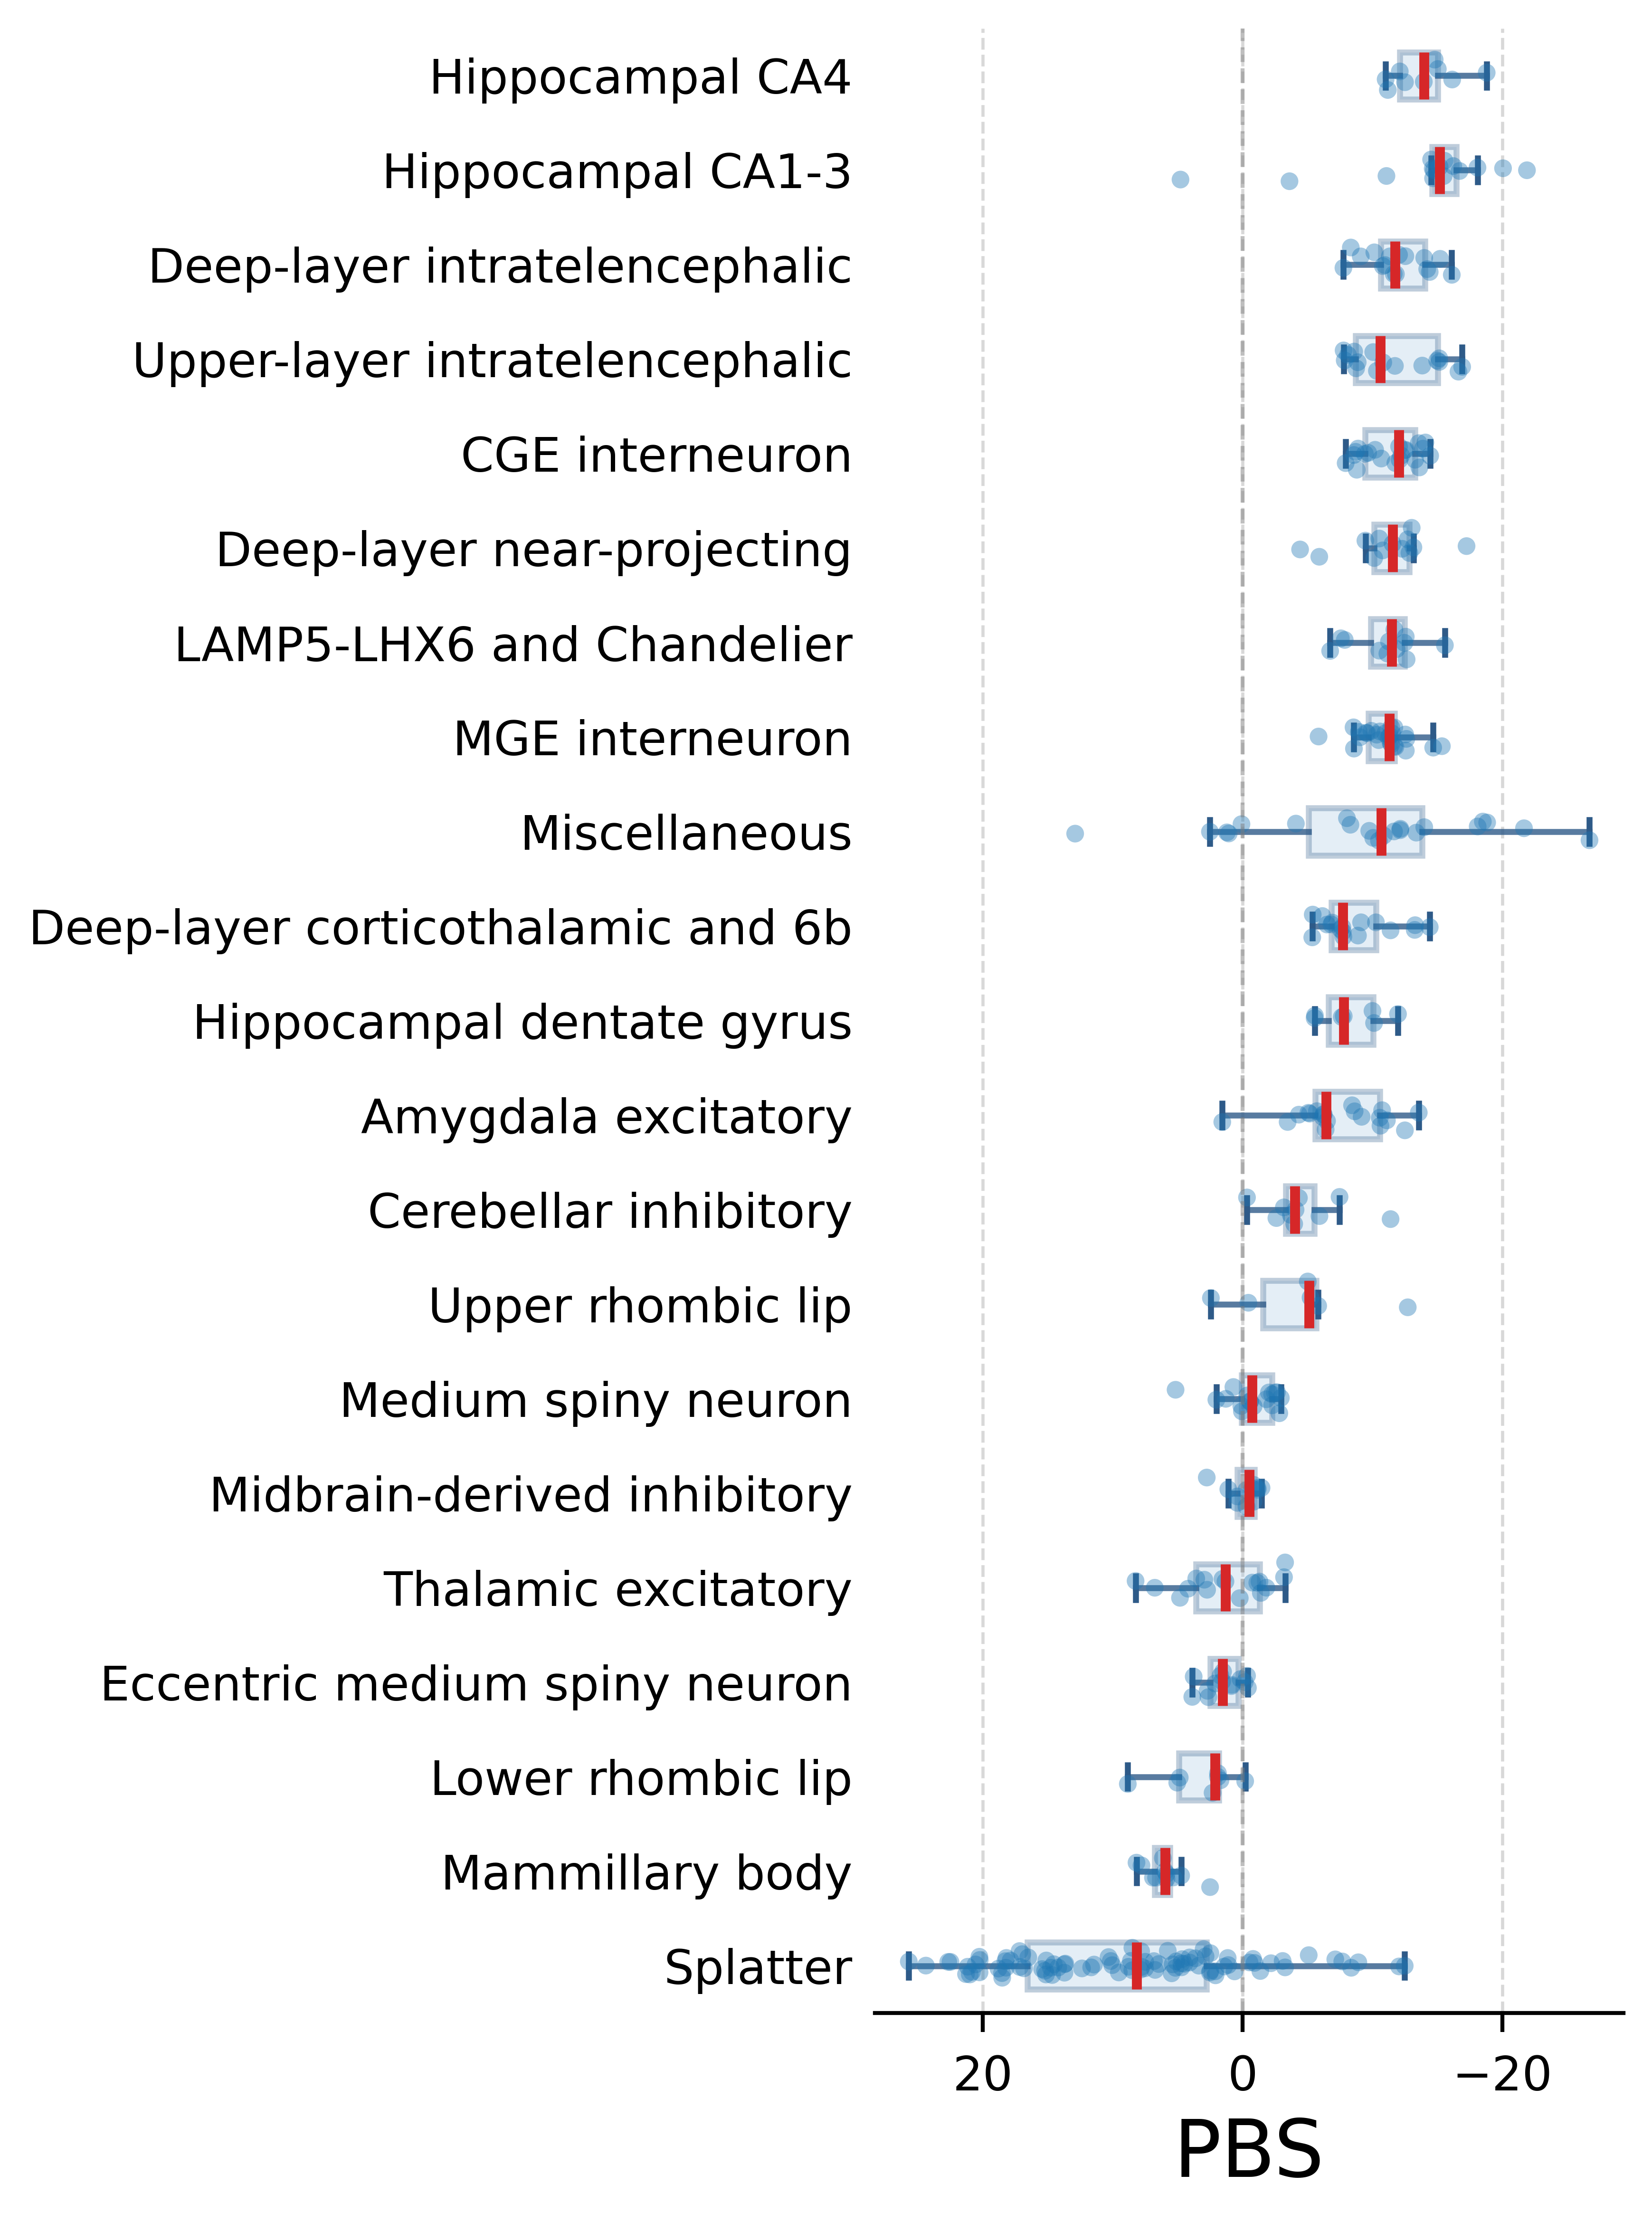

In [75]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_LGD, flip_axis=True, figsize=(6, 8))

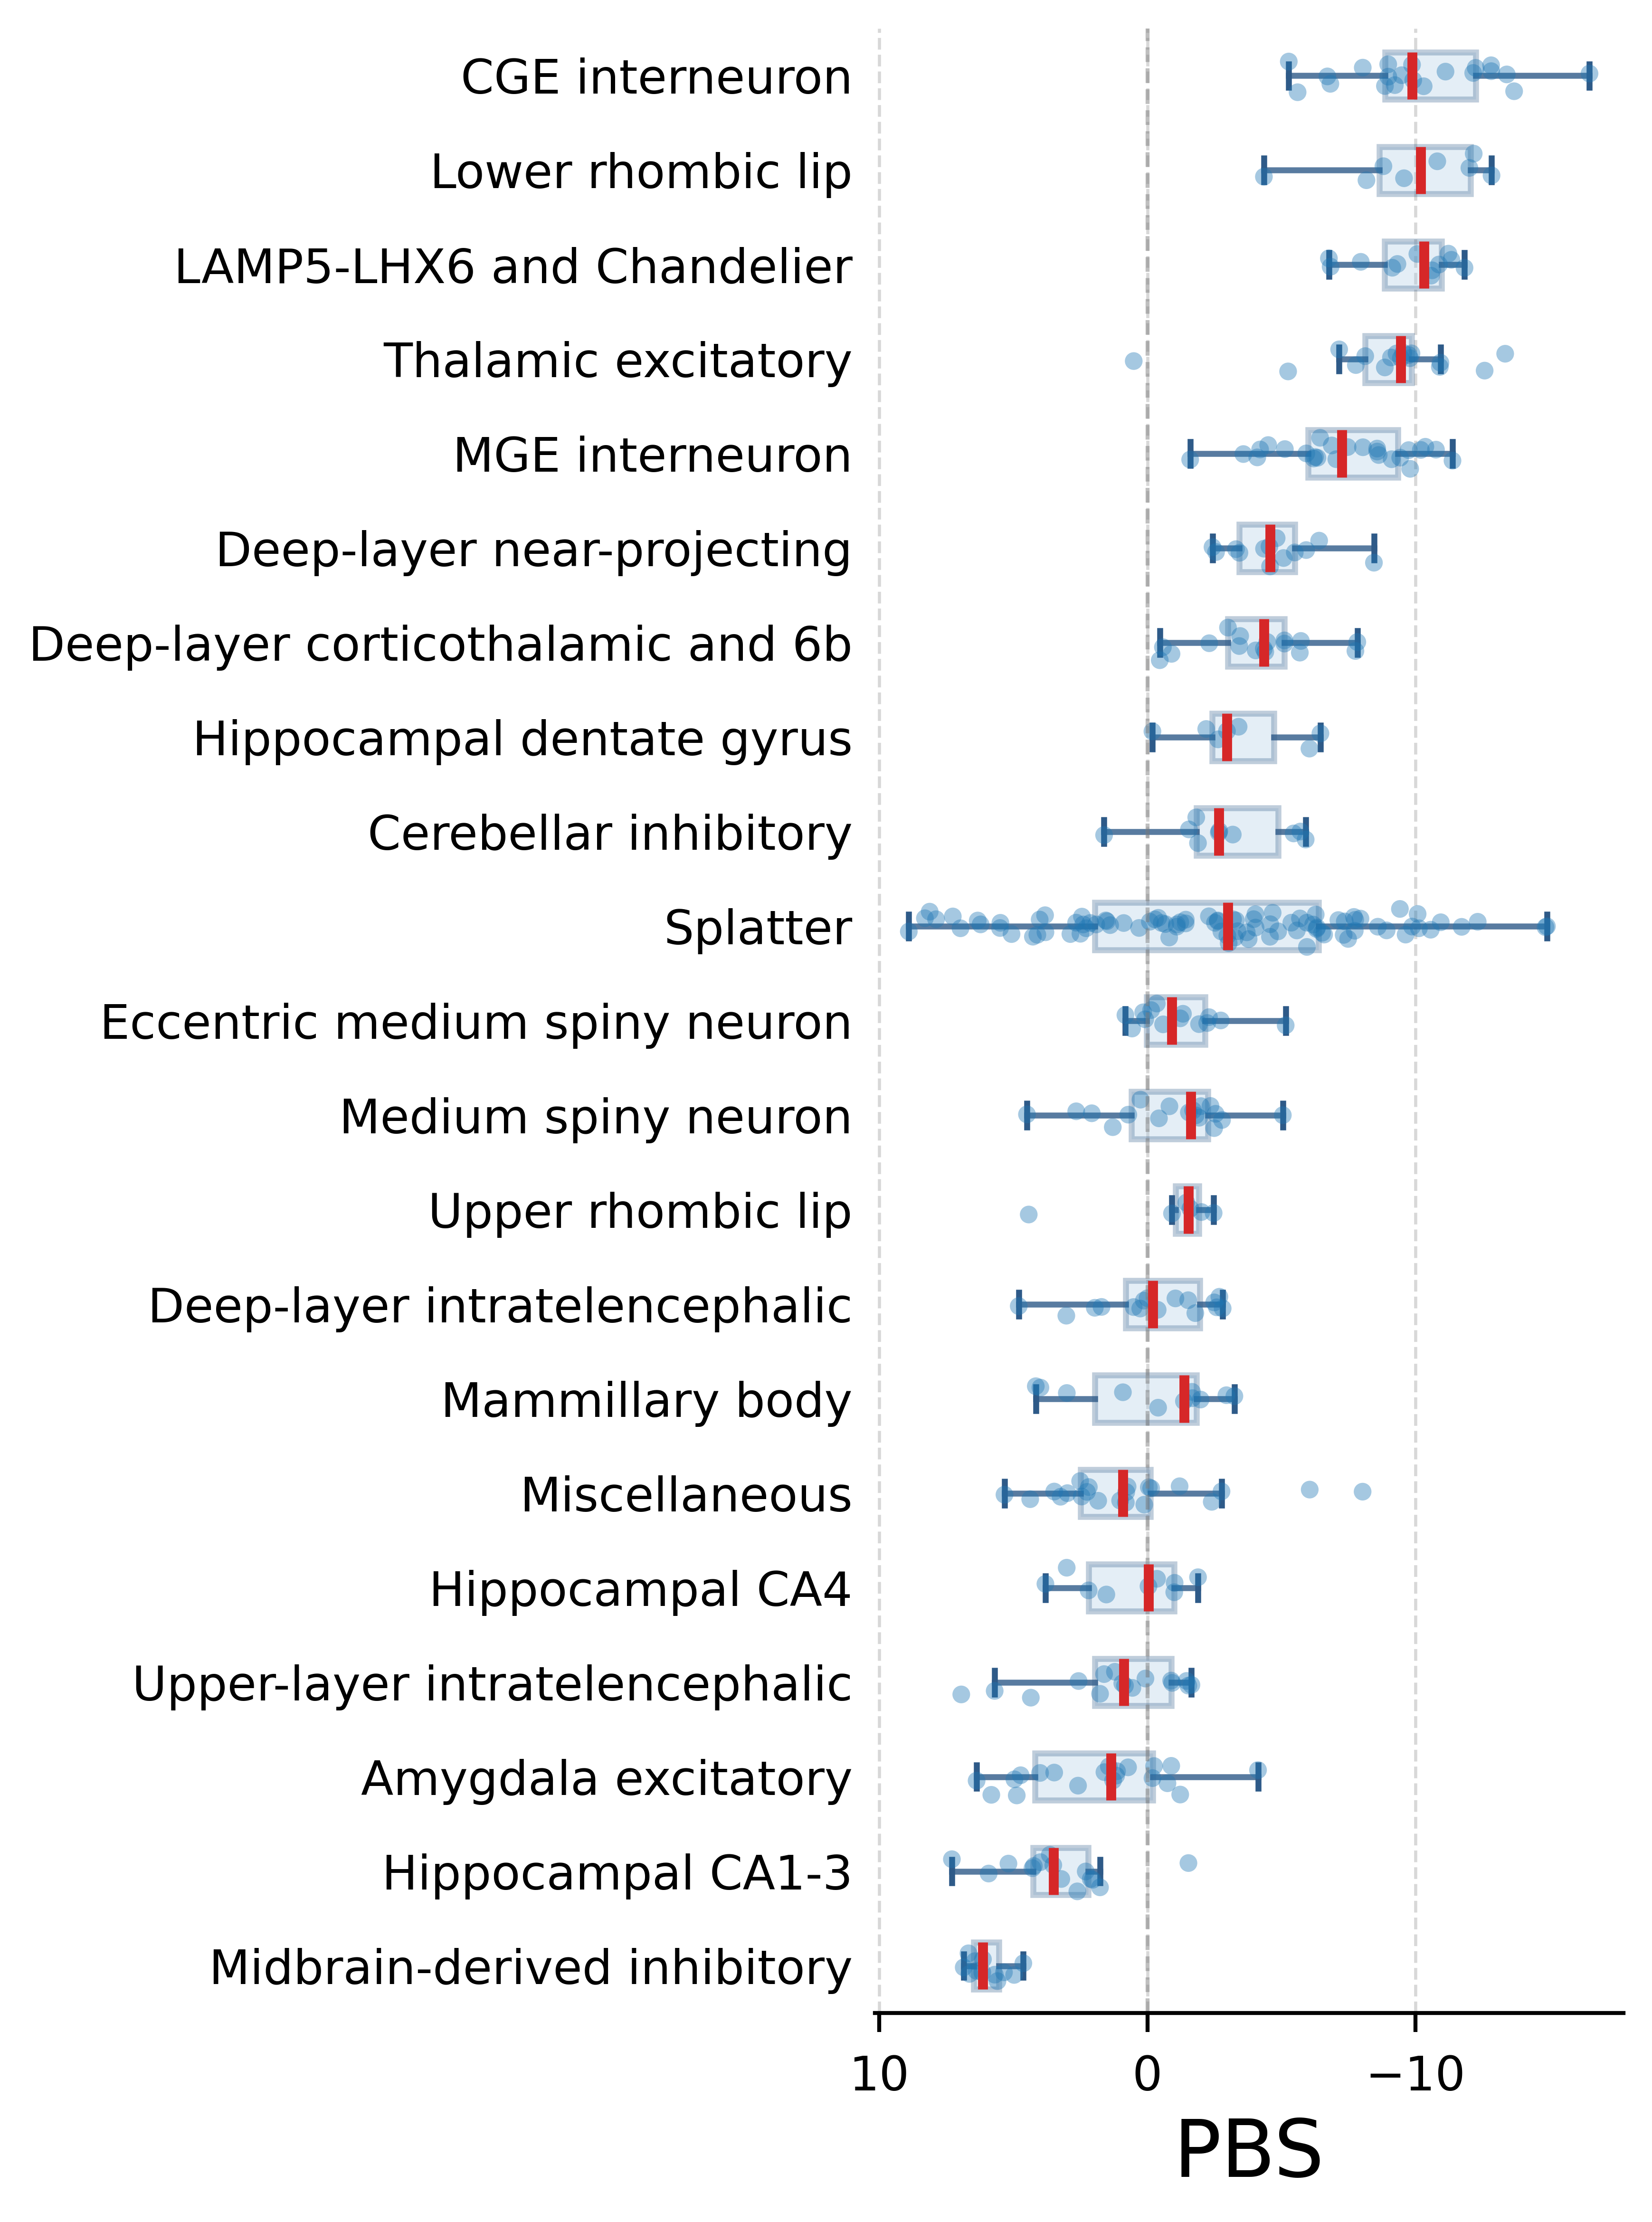

In [76]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_Dmis, flip_axis=True, figsize=(6, 8))

In [77]:
Perm_DIR_LGD = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/LGD/"
Perm_DFs_LGD = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_LGD):
    df = pd.read_csv(f"{Perm_DIR_LGD}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_LGD.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_LGD))

Perm_DIR_Dmis = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/Dmis/"
Perm_DFs_Dmis = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_Dmis):
    df = pd.read_csv(f"{Perm_DIR_Dmis}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_Dmis.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_Dmis))

10000
10000


In [78]:
HumanCT_res_df_GeneL_LGD

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
266,266,LAMP5-LHX6 and Chandelier,-0.367454,0.007988,-0.269532,0.055788,-11.680815,-23.661771,0.300142,64.790985,0.072647,0.055788,5.961935
185,185,Hippocampal CA1-3,-0.344896,0.013191,-0.439947,0.001236,-20.046093,-31.792995,-8.299192,66.592386,0.193553,0.001236,5.845465
276,276,CGE interneuron,-0.343425,0.013614,-0.308955,0.027387,-14.068707,-26.501839,-1.635575,65.819044,0.095453,0.027387,6.186945
267,267,LAMP5-LHX6 and Chandelier,-0.329570,0.018194,-0.319330,0.022366,-15.571207,-28.837031,-2.305383,65.050341,0.101971,0.022366,6.601307
188,188,Hippocampal CA1-3,-0.326538,0.019354,-0.444689,0.001078,-21.887235,-34.543220,-9.231250,67.022127,0.197748,0.001078,6.297841
...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,338,Splatter,0.257438,0.068186,0.289409,0.039412,13.716998,0.692560,26.741435,64.680032,0.083757,0.039412,6.481189
75,75,Committed oligodendrocyte precursor,0.263909,0.061305,0.203057,0.152975,11.549173,-4.438902,27.537247,64.879345,0.041232,0.152975,7.955947
342,342,Splatter,0.270652,0.054739,0.335915,0.015956,15.208673,2.966191,27.451154,63.973696,0.112839,0.015956,6.092074
345,345,Splatter,0.272785,0.052784,0.353667,0.010898,16.961877,4.083243,29.840511,64.215031,0.125080,0.010898,6.408635


In [79]:
results_df_LGD = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_LGD, p_beta_LGD = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_LGD, Perm_DFs_LGD, plot=False)
    
    # Add results to DataFrame
    results_df_LGD = results_df_LGD.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_LGD,
        'p_beta': p_beta_LGD
    }, ignore_index=True)

/tmp/ipykernel_249261/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_249261/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_249261/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_249261/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_249261/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future vers

In [80]:
results_df_Dmis = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_Dmis, p_beta_Dmis = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_Dmis, Perm_DFs_Dmis, plot=False)
    
    # Add results to DataFrame
    results_df_Dmis = results_df_Dmis.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_Dmis,
        'p_beta': p_beta_Dmis
    }, ignore_index=True)

/tmp/ipykernel_249261/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_249261/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_249261/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_249261/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_249261/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a fut

In [81]:
results_df_LGD

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.1247,0.0007
1,CGE interneuron,0.0515,0.0004
2,Cerebellar inhibitory,0.2444,0.0085
3,Deep-layer corticothalamic and 6b,0.1417,0.0016
4,Deep-layer intratelencephalic,0.1041,0.0000
5,Deep-layer near-projecting,0.1694,0.0014
6,Eccentric medium spiny neuron,0.5598,0.6697
7,Hippocampal CA1-3,0.0112,0.0000
8,Hippocampal CA4,0.0593,0.0000
9,Hippocampal dentate gyrus,0.1704,0.0019


In [82]:
results_df_Dmis

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.4165,0.8014
1,CGE interneuron,0.0481,0.0000
2,Cerebellar inhibitory,0.4198,0.0441
3,Deep-layer corticothalamic and 6b,0.0475,0.0568
4,Deep-layer intratelencephalic,0.1995,0.4563
5,Deep-layer near-projecting,0.2335,0.1162
6,Eccentric medium spiny neuron,0.6140,0.3824
7,Hippocampal CA1-3,0.7383,0.8905
8,Hippocampal CA4,0.3505,0.5702
9,Hippocampal dentate gyrus,0.0842,0.1830


# UKBB